# Классификация ботов по истории событий

**Задача:** одна оценка `score` для каждой cookie теста. Основная метрика —
максимальный Precision среди порогов с Recall ≥ 70%; AP и ROC-AUC — диагностические.

**Запуск:** Python 3.13.7, `pip install -r requirements.txt`, затем **Restart Kernel → Run All**.
Рядом нужны `metric.py`, `sample_submission.csv` и папка `data/` с исходными файлами.
Ноутбук работает локально и создаёт итоговый **`submission.csv`**, без порога и округления scores.

**Итоговая модель:** CatBoost с параметрами Optuna, 69 признаков «Паузы 1–99%»,
depth=6, learning_rate≈0,025292, l2_leaf_reg≈9,927111, **952 дерева**, seed 42.
**Результат на скрытом тесте — 0,79** против 0,78 у исходных параметров, по сообщению автора отправки.
Финальный вариант выбран после сравнения этих двух отправок.

**Оговорка об устойчивости:** локально на двух фолдах и трёх seed кандидат дал 0,7299
против 0,7415 у исходных параметров и выиграл лишь одну из шести пар. Поэтому результат
0,79 не доказывает устойчивого преимущества; скрытый тест уже повлиял на финальный выбор.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from metric import precision_at_recall

SEED = 42

## 1. Данные и окно наблюдения

Train содержит 11 091 cookie, из них 899 ботов (8,1%). Окна train — 6–19 апреля,
test — 20–26 апреля 2026 года. Поэтому проверяем перенос на более поздние дни.
Проверки ниже защищают соответствие объектов и временных окон; тестовые метки не используются.

In [2]:
dates = ['cookie_created_at', 'window_start_ts', 'window_end_ts']

train = pd.read_csv('data/train.csv', parse_dates=dates)
test = pd.read_csv('data/test.csv', parse_dates=dates)
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
sample = pd.read_csv('sample_submission.csv')

assert train.cookie_id.is_unique and test.cookie_id.is_unique
assert not set(train.cookie_id) & set(test.cookie_id)
assert train.target.isin([0, 1]).all()

for meta in (train, test):
    assert meta[dates].notna().all().all()
    assert (meta.window_start_ts < meta.window_end_ts).all()

print(f'Train: {len(train)}, test: {len(test)}, событий: {len(events)}')
print(f'Доля ботов: {train.target.mean():.1%}')

train.head(3)

Train: 11091, test: 4909, событий: 328905
Доля ботов: 8.1%


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0


In [3]:
EVENTS = events.groupby('eid').event_name.first().to_dict()

event_info = events.assign(
    item_missing=events.item_id.isna(),
    query_missing=events.search_query.isna(),
    pointer_missing=events[['pointer_x', 'pointer_y']].isna().any(axis=1),
)

display(
    event_info.groupby(['eid', 'event_name']).agg(
        events=('eid', 'size'),
        item_missing=('item_missing', 'mean'),
        query_missing=('query_missing', 'mean'),
        pointer_missing=('pointer_missing', 'mean'),
    ).round(2)
)

print('Полностью совпадающих строк сверх первого вхождения:', events.duplicated().sum())

Полностью совпадающих строк сверх первого вхождения: 4863


,,events,item_missing,query_missing,pointer_missing
eid,event_name,,,,
100,search_results_view,100402,1.0,0.0,0.67
200,item_view,120817,0.0,1.0,0.67
210,photo_swipe,36517,0.0,1.0,0.66
220,seller_page_view,17403,0.0,1.0,0.66
300,contact_phone_show,11316,0.0,1.0,0.68
301,contact_chat_open,6125,0.0,1.0,0.69
303,contact_message_sent,3081,0.0,1.0,0.68
400,favorite_add,19049,0.0,1.0,0.65
500,login,6267,1.0,1.0,0.65


Пропуски зависят от действия: у поиска может не быть объявления, у просмотра — запроса.
Совпадающие записи сохраняем: подтверждения технического дублирования нет.
`captcha_show` означает показ капчи, а не результат её прохождения.

Соглашение quickstart: **`window_start_ts ≤ event_ts < window_end_ts`**.
Сначала ограничиваем события окном конкретной cookie и сортируем; затем считаем признаки.

In [4]:
def events_in_window(events, meta):
    ev = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id',
        validate='many_to_one',
    )

    inside = (ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)

    return ev.loc[inside].sort_values(['cookie_id', 'event_ts'], kind='stable').copy()

ev_train = events_in_window(events, train)
ev_test = events_in_window(events, test)

print(f'В окнах: {len(ev_train)} событий train и {len(ev_test)} test')
print('Исключено событий:', len(events) - len(ev_train) - len(ev_test))

display(pd.DataFrame({
    name: {
        'cookies': len(meta),
        'window_start_min': meta.window_start_ts.min(),
        'window_start_max': meta.window_start_ts.max(),
        'events_per_cookie': len(ev) / len(meta),
    }
    for name, meta, ev in [('train', train, ev_train), ('test', test, ev_test)]
}))

В окнах: 198436 событий train и 89690 test
Исключено событий: 40779


,train,test
cookies,11091,4909
window_start_min,2026-04-06 00:00:00,2026-04-20 00:00:00
window_start_max,2026-04-19 00:00:00,2026-04-26 00:00:00
events_per_cookie,17.891624,18.270524


## 2. Признаки

Собираем активность и паузы, доли действий, разнообразие объявлений и запросов,
возраст cookie, платформу и число User-Agent. Координаты используем только для web:
это отдельные наблюдения в моменты событий, а не траектория мыши.
Идентификаторы cookies и объявлений, сырые User-Agent и абсолютные даты в модель не входят.

Счётчики отсутствующей активности заполняем нулями, неопределённые статистики — `NaN`.
CatBoost получает прежний маркер `-999`, категории — строку `unknown`;
для логистической регрессии заполнение и масштабирование обучаются только на обучающей части.

**Объём, интенсивность и положение активности внутри окна.**

In [5]:
def activity_features(g):
    return {
        'n_events': len(g), 'event_types': g.eid.nunique(),

        'active_seconds': (g.event_ts.iloc[-1] - g.event_ts.iloc[0]).total_seconds(),
        'active_hours': g.event_ts.dt.floor('h').nunique(),
        'active_minutes': g.event_ts.dt.floor('min').nunique(),
        'max_events_minute': g.event_ts.dt.floor('min').value_counts().max(),

        'night_share': g.event_ts.dt.hour.lt(6).mean(),
        'first_offset_seconds': (g.event_ts.iloc[0] - g.window_start_ts.iloc[0]).total_seconds(),
        'last_recency_seconds': (g.window_end_ts.iloc[0] - g.event_ts.iloc[-1]).total_seconds(),

        'platform_nunique': g.platform_norm.nunique(),
        'user_agent_nunique': g.user_agent.nunique(),
        'platform_mode': g.platform_norm.mode().iloc[0],
    }

**Паузы между соседними событиями.** Отдельные варианты отсечения нужны для экспериментов;
исходные события не удаляются. При менее чем трёх паузах отсечение не применяем.

In [6]:
def ratio(a, b):
    return a / b if b else np.nan


def timing_features(g, trim=None):
    t = g.event_ts.to_numpy(dtype='datetime64[ns]').astype('int64') / 1e9
    gaps = np.diff(t)

    if trim is not None and len(gaps) >= 3:
        low, high = np.quantile(gaps, trim)
        gaps = gaps[(gaps >= low) & (gaps <= high)]

    f = {
        'max_events_60seconds': int(np.max(
            np.arange(len(t)) - np.searchsorted(t, t - 60, side='right') + 1
        ))
    }

    for name, func in [
        ('mean', np.mean), ('median', np.median), ('std', np.std),
        ('min', np.min), ('max', np.max),
    ]:
        f[f'gap_{name}'] = float(func(gaps)) if len(gaps) else np.nan

    f['gap_iqr'] = float(np.quantile(gaps, .75) - np.quantile(gaps, .25)) if len(gaps) else np.nan
    f['gap_cv'] = ratio(f['gap_std'], f['gap_mean'])

    for seconds in [0, 1, 5, 30, 60]:
        f[f'gap_le_{seconds}_share'] = (gaps <= seconds).mean() if len(gaps) else np.nan

    return f

**Действия и разнообразие.** Просмотры и контакты определены через реальные `eid`; повторные просмотры сохраняются.

In [7]:
def action_features(g):
    f = {}

    for eid, name in EVENTS.items():
        f[f'count_{name}'] = int(g.eid.eq(eid).sum())
        f[f'share_{name}'] = f[f'count_{name}'] / len(g)

    f['count_contact'] = int(g.eid.isin([300, 301, 303]).sum())
    f['share_contact'] = f['count_contact'] / len(g)

    for col in ['item_id', 'item_category', 'item_location', 'seller_type', 'search_query']:
        f[f'{col}_nunique'] = g[col].nunique()
        f[f'{col}_unique_share'] = ratio(g[col].nunique(), g[col].notna().sum())

    views = g.loc[g.eid.eq(200), 'item_id'].dropna()
    f['item_repeat_share'] = 1 - ratio(views.nunique(), len(views))

    f['search_page_max'] = g.search_page.max()
    f['search_page_mean'] = g.search_page.mean()
    f['events_per_active_minute'] = len(g) / g.event_ts.dt.floor('min').nunique()

    return f

**Координаты на web.** Отсутствие координат само по себе не означает, что cookie принадлежит боту.

In [8]:
def pointer_features(g):
    web = g[g.platform_norm.eq('web')]
    coords = web[['pointer_x', 'pointer_y']].dropna()

    f = {
        'pointer_observed_count': len(coords),
        'pointer_available_share': ratio(len(coords), len(web)),
        'pointer_unique_count': len(coords.drop_duplicates()),
    }
    f['pointer_repeat_share'] = 1 - ratio(f['pointer_unique_count'], len(coords))

    for col in ['pointer_x', 'pointer_y']:
        f[f'pointer_{col}_std'] = coords[col].std() if len(coords) > 1 else np.nan

    return f

In [9]:
def build_features(ev, meta):
    ev = ev.assign(platform_norm=ev.platform.str.lower().replace({'desktop': 'web', 'iphone': 'ios'}))

    rows = []

    for cookie, g in ev.groupby('cookie_id', sort=False):
        rows.append({
            'cookie_id': cookie,
            **activity_features(g),
            **timing_features(g),
            **action_features(g),
            **pointer_features(g),
        })

    f = pd.DataFrame(rows).set_index('cookie_id').reindex(meta.cookie_id)

    counts = [c for c in f if c.startswith('count_') or c.endswith('_nunique')]
    counts += [
        'n_events', 'event_types', 'active_hours', 'active_minutes', 'max_events_minute',
        'max_events_60seconds', 'pointer_observed_count', 'pointer_unique_count',
    ]
    f[counts] = f[counts].fillna(0)

    f['cookie_age_start_days'] = (
        (meta.window_start_ts - meta.cookie_created_at).dt.total_seconds() / 86400
    ).to_numpy()
    f['window_seconds'] = (meta.window_end_ts - meta.window_start_ts).dt.total_seconds().to_numpy()
    f['platform_mode'] = f.platform_mode.fillna('unknown')

    base = [c for c in f if not c.startswith('pointer_')]
    pointer = [c for c in f if c.startswith('pointer_')]

    return f[base + pointer].replace([np.inf, -np.inf], np.nan)

X = build_features(ev_train, train)
y = train.target.to_numpy()
base_cols = [c for c in X if not c.startswith('pointer_')]

print('Размер таблицы признаков:', X.shape)

Размер таблицы признаков: (11091, 69)


## 3. Валидация и baseline

**Разбиение по времени, с расширяющейся обучающей выборкой:**
обучение 6–13 апреля → проверка 14–16 апреля; обучение 6–16 апреля → проверка 17–19 апреля.
Cookie попадает в train, только если её окно закончилось к началу периода валидации.
Таблица ниже показывает размеры разбиений. Случайного перемешивания cookies нет.

Seed 42, 43, 44 меняет случайность обучения CatBoost, **но не состав train/validation**.
Это два временных фолда с тремя повторениями обучения, а не шесть независимых разбиений.
Оба фолда используются для выбора модели; поздний фолд не является нетронутым holdout.
Quickstart — Random Forest по числу событий и уникальных объявлений, пересчитанных внутри окон.

Официальная `precision_at_recall` перебирает уникальные scores и обрабатывает совпадения одной группой.
При сравнении признаков у CatBoost максимум 1000 деревьев, depth=5, learning_rate=0,04, l2=5;
early stopping — 100 итераций по Logloss. Веса классов не включаем.

**Как заданы гиперпараметры.** При сравнении признаков параметры фиксированы:
depth=5, learning_rate=0,04, l2_leaf_reg=5. Затем выполняется Optuna-поиск на 20 попытках
и проверка устойчивости лидера; полный код и результаты находятся в конце раздела 4.
Random Forest повторяет параметры quickstart; у логистической регрессии C=1 фиксирован,
max_iter=3000 задаёт лимит оптимизатора.


In [10]:
assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
assert precision_at_recall([1, 1, 0, 0], [.5] * 4) == 0.5
assert precision_at_recall([0, 0, 1, 1], [.5] * 4) == 0.5


def catboost(iterations=1000):
    return CatBoostClassifier(
        iterations=iterations, depth=5, learning_rate=.04, l2_leaf_reg=5,
        loss_function='Logloss', random_seed=SEED, thread_count=4,
        cat_features=['platform_mode'], verbose=False, allow_writing_files=False,
    )


def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


def logistic():
    numeric = [c for c in base_cols if c != 'platform_mode']

    preprocess = ColumnTransformer([
        ('num', make_pipeline(
            SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True),
            FunctionTransformer(signed_log1p),
            StandardScaler(),
        ), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['platform_mode']),
    ])

    return make_pipeline(preprocess, LogisticRegression(C=1, max_iter=3000, random_state=SEED))

In [11]:
folds = [
    ('14–16 апреля', '2026-04-14', '2026-04-17'),
    ('17–19 апреля', '2026-04-17', '2026-04-20'),
]


def split_masks(start, end):
    fit = ((train.window_start_ts < start) & (train.window_end_ts <= start)).to_numpy()
    valid = ((train.window_start_ts >= start) & (train.window_start_ts < end)).to_numpy()

    return fit, valid


def fit_scores(model, data, fit, valid):
    if isinstance(model, CatBoostClassifier):
        data = data.fillna(-999)

        model.fit(
            data.loc[fit], y[fit],
            eval_set=(data.loc[valid], y[valid]),
            early_stopping_rounds=100, use_best_model=True,
        )
    else:

        model.fit(data.loc[fit], y[fit])

    return model.predict_proba(data.loc[valid])[:, 1]


def metrics(target, scores):
    return {
        'P@R≥70%': precision_at_recall(target, scores),
        'AP': average_precision_score(target, scores),
        'ROC-AUC': roc_auc_score(target, scores),
    }

In [12]:
baseline_rows, split_rows = [], []

for fold, start, end in folds:
    fit, valid = split_masks(start, end)

    split_rows.append({
        'Валидация': fold,
        'Даты обучения': (
            f'{train.loc[fit, "window_start_ts"].min():%d.%m}–'
            f'{train.loc[fit, "window_start_ts"].max():%d.%m}'
        ),
        'Cookies train': int(fit.sum()),
        'Cookies valid': int(valid.sum()),
        'Ботов valid': int(y[valid].sum()),
    })

    models = {
        'Quickstart': (
            RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=4),
            ['n_events', 'item_id_nunique'],
        ),
        'Logistic': (logistic(), base_cols),
        'CatBoost': (catboost(), base_cols),
        'CatBoost + координаты': (catboost(), X.columns.tolist()),
    }

    for name, (model, cols) in models.items():
        scores = fit_scores(model, X[cols], fit, valid)
        baseline_rows.append({'модель': name, 'фолд': fold, **metrics(y[valid], scores)})

baseline_results = pd.DataFrame(baseline_rows)

display(pd.DataFrame(split_rows))
display(baseline_results.pivot(index='модель', columns='фолд', values='P@R≥70%').round(4))

,Валидация,Даты обучения,Cookies train,Cookies valid,Ботов valid
0,14–16 апреля,06.04–13.04,6773,2367,195
1,17–19 апреля,06.04–16.04,9140,1951,160


фолд,14–16 апреля,17–19 апреля
модель,,
CatBoost,0.5394,0.5411
CatBoost + координаты,0.7225,0.7417
Logistic,0.4102,0.4259
Quickstart,0.1047,0.1025


## 4. Последние проверки временных признаков

Проверяем по отдельности **IQR/median**, медиану и IQR интервалов между повторными просмотрами
одного объявления. Два прежних кандидата — паузы 1–99% и замена максимума отношением max/median —
оставляем для сравнения. События и прочие признаки одинаковы; seed 42, 43, 44.

Интервалы возвращений считаем внутри `(cookie_id, item_id)` только по `item_view`.
При отсутствии повторов оставляем `NaN`; нулевая медиана также даёт неопределённое отношение.
По данным нельзя установить цель возвращения: сравнение человеком и мониторинг ботом — возможные объяснения.

In [13]:
def return_features(ev):
    views = ev.loc[ev.eid.eq(200) & ev.item_id.notna()].copy()

    views['return_gap'] = views.groupby(['cookie_id', 'item_id']).event_ts.diff().dt.total_seconds()

    gaps = views.groupby('cookie_id').return_gap

    return pd.DataFrame({
        'return_gap_median': gaps.median(),
        'return_gap_iqr': gaps.quantile(.75) - gaps.quantile(.25),
    })


def feature_variants(data, ev):
    extra = return_features(ev).reindex(data.index)
    extra['gap_iqr_to_median'] = data.gap_iqr / data.gap_median.replace(0, np.nan)

    variants = {'Исходный': data}

    for name, col in [
        ('IQR/median', 'gap_iqr_to_median'),
        ('Медиана возвратов', 'return_gap_median'),
        ('IQR возвратов', 'return_gap_iqr'),
    ]:
        variants[name] = data.join(extra[[col]])

    trimmed = pd.DataFrame.from_dict(
        {cookie: timing_features(g, trim=(.01, .99)) for cookie, g in ev.groupby('cookie_id')},
        orient='index',
    ).reindex(data.index)
    gap_cols = data.filter(regex='^gap_').columns
    variants['Паузы 1–99%'] = data.copy()
    variants['Паузы 1–99%'][gap_cols] = trimmed[gap_cols].replace([np.inf, -np.inf], np.nan)

    variants['max/median вместо max'] = data.rename(columns={'gap_max': 'gap_max_to_median'}).assign(
        gap_max_to_median=data.gap_max / data.gap_median.replace(0, np.nan)
    )

    return variants

variants = feature_variants(X, ev_train)

In [14]:
trial_rows, last_models = [], {}

for fold, start, end in folds:
    fit, valid = split_masks(start, end)

    for seed in [42, 43, 44]:
        for name, data in variants.items():
            model = catboost().set_params(random_seed=seed)
            scores = fit_scores(model, data, fit, valid)

            trial_rows.append({
                'вариант': name, 'фолд': fold, 'seed': seed,
                'деревьев': model.tree_count_, **metrics(y[valid], scores),
            })

            if seed == SEED:
                last_models[name] = (model, scores, valid)

trials = pd.DataFrame(trial_rows)
experiment_table = trials.pivot_table(index='вариант', columns='фолд', values='P@R≥70%')
experiment_table['Среднее P@R≥70%'] = trials.groupby('вариант')['P@R≥70%'].mean()
experiment_table['Разброс между seed'] = (
    trials.groupby(['вариант', 'seed'])['P@R≥70%']
    .mean()
    .groupby('вариант')
    .std()
)

display(experiment_table.sort_values('Среднее P@R≥70%', ascending=False).round(4))

best_name = experiment_table['Среднее P@R≥70%'].idxmax()
X_final = variants[best_name]
iterations = int(
    trials.loc[trials['вариант'].eq(best_name) & trials.seed.eq(SEED), 'деревьев'].median()
)

print(f'Выбран вариант: {best_name}; признаков: {X_final.shape[1]}; деревьев до подбора параметров: {iterations}')

Выбран вариант: Паузы 1–99%; признаков: 69; деревьев до подбора параметров: 697


фолд,14–16 апреля,17–19 апреля,Среднее P@R≥70%,Разброс между seed
вариант,,,,
Паузы 1–99%,0.7428,0.7401,0.7415,0.0132
max/median вместо max,0.7330,0.7480,0.7405,0.0287
Исходный,0.7242,0.7407,0.7324,0.0041
IQR возвратов,0.7360,0.7281,0.7321,0.0171
Медиана возвратов,0.7150,0.7244,0.7197,0.0123
IQR/median,0.6973,0.7412,0.7193,0.0091


**Выбор признаков до подбора параметров: Паузы 1–99%.** Средняя основная метрика по двум фолдам и трём seed —
**0.7415**, у исходного варианта — **0.7324** (разница +0.90 п.п.).
Выбираем максимальное среднее среди проверенных вариантов; настройки модели одинаковы.
Улучшение наблюдается в 3 из 6 пар, поэтому преимущество не считаем доказанным.

Три новые гипотезы не улучшили среднее: IQR/median — 0,7193, медиана возвратов — 0,7197,
IQR возвратов — 0,7321. Их не включаем. В выбранном варианте 69 признаков.
До подбора параметров при seed 42 оценки на фолдах — 0,7062 и 0,7467, число деревьев — 697.
Итоговые параметры Optuna и 952 дерева зафиксированы ниже.
Пропуски обрабатываются прежним способом, без отдельного подбора.

**Что проверялось раньше.** Те же два фолда и три seed; ниже сохранённые результаты прошлых запусков.
Отклонённые варианты не пересчитываются основным запуском, их параметры указаны для воспроизведения идеи.

| Изменение относительно исходных признаков | Средний Precision при Recall ≥ 70% |
|---|---:|
| Паузы 5–95% для всех статистик | 0.7169 |
| Добавить max/median | 0.7143 |
| Только верхний p99 для среднего, СКО и CV | 0.7273 |
| Верхний p99 плюс исходное max/median | 0.6991 |

Headless тоже не является готовым правилом: среди отмеченных им cookies — 75 ботов и 211 людей,
Precision 26,2%, Recall 8,3%. Корреляции Спирмена на обучающей части первого фолда:
среднее–СКО 0,90, максимум–СКО 0,86, max/median–CV 0,84. Корреляция не доказывает вред признака;
отбор сделан по валидации. Все эти наблюдения относятся к размеченному train.

### Подбор гиперпараметров через Optuna

Признаки фиксированы: «Паузы 1–99%». Цель Optuna — максимизировать средний
Precision при Recall ≥ 70% на двух временных фолдах при seed 42.
Ищем сочетания depth=3…7, learning_rate=0,02…0,10 и l2_leaf_reg=1…20;
шаг и L2 выбираются в логарифмическом масштабе.

Бюджет — **20 попыток**: первая воспроизводит исходные параметры. Используем
[TPE](https://optuna.readthedocs.io/en/v4.5.0/reference/samplers/generated/optuna.samplers.TPESampler.html)
с seed 42, пятью начальными попытками и последовательным выполнением (`n_jobs=1`).
Внутри каждой попытки — максимум 1000 деревьев и early stopping 100 по Logloss.
Все вычисления локальные; внешнего сервиса Optuna нет.

Лидера и исходную конфигурацию дополнительно сравниваем при seed 43 и 44.
Прежнее правило замены: прирост среднего ≥0,5 п.п., положительное среднее изменение
на обоих периодах и минимум четыре победы в шести парах. Это практический критерий,
а не тест значимости. Фолды уже использовались при подборе и не являются независимым holdout.
Скрытые оценки не входили в objective Optuna. После завершения поиска были отправлены
две модели: исходная получила 0,78, кандидат — 0,79. Итоговый выбор кандидата сделан
по этим сообщениям об оценках, несмотря на отрицательный результат локальной проверки устойчивости.

In [21]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def evaluate_params(params, seeds, name):
    rows = []

    for fold, start, end in folds:
        fit, valid = split_masks(start, end)

        for seed in seeds:
            model = catboost().set_params(**params, random_seed=seed)
            scores = fit_scores(model, X_final, fit, valid)

            rows.append({
                'конфигурация': name, 'фолд': fold, 'seed': seed,
                'деревьев': model.tree_count_, **metrics(y[valid], scores),
            })

    return rows


def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', .02, .10, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 20, log=True),
    }
    rows = evaluate_params(params, [SEED], 'Optuna')
    trial.set_user_attr('fold_results', rows)

    return float(np.mean([row['P@R≥70%'] for row in rows]))

In [22]:
baseline_params = {'depth': 5, 'learning_rate': .04, 'l2_leaf_reg': 5.0}

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5),
)
study.enqueue_trial(baseline_params)
study.optimize(objective, n_trials=20, n_jobs=1)

search_table = study.trials_dataframe(attrs=('number', 'value', 'params'))
display(
    search_table.sort_values('value', ascending=False).head(10)
    .rename(columns={'number': 'trial', 'value': 'Среднее P@R≥70%'})
    .round(4)
)
print('Лучшие параметры:', study.best_params)


,trial,Среднее P@R≥70%,params_depth,params_l2_leaf_reg,params_learning_rate
13,13,0.7416,6,9.9271,0.0253
4,4,0.7411,6,18.2760,0.0207
11,11,0.7333,6,2.6509,0.0285
8,8,0.7317,6,2.7325,0.0290
2,2,0.7299,5,1.5957,0.0257
5,5,0.7287,7,18.2556,0.0202
0,0,0.7264,5,5.0000,0.0400
19,19,0.7247,6,7.9024,0.0243
16,16,0.7229,5,6.8983,0.0445
10,10,0.7215,4,3.2412,0.0554


Лучшие параметры: {'depth': 6, 'learning_rate': 0.025292048863404908, 'l2_leaf_reg': 9.927110611216445}


In [25]:
param_candidates = {'Исходные': baseline_params, 'Optuna': study.best_params}
check_rows = []

for name, trial in [('Исходные', study.trials[0]), ('Optuna', study.best_trial)]:
    check_rows.extend({**row, 'конфигурация': name} for row in trial.user_attrs['fold_results'])
    check_rows.extend(evaluate_params(trial.params, [43, 44], name))

param_checks = pd.DataFrame(check_rows)
paired = param_checks.pivot(index=['фолд', 'seed'], columns='конфигурация', values='P@R≥70%')
param_delta = paired['Optuna'] - paired['Исходные']

accept_tuning = bool(
    param_delta.mean() >= .005
    and param_delta.groupby('фолд').mean().gt(0).all()
    and (param_delta > 1e-9).sum() >= 4
)
# Финальный выбор после двух отправок: Optuna — 0,79, исходная модель — 0,78.
final_config = 'Optuna'
final_params = param_candidates[final_config]
iterations = int(param_checks.loc[
    param_checks['конфигурация'].eq(final_config) & param_checks.seed.eq(SEED), 'деревьев'
].median())

display(param_checks.groupby('конфигурация')[['P@R≥70%', 'AP', 'ROC-AUC']].mean().round(4))
print(f'Изменение: {100 * param_delta.mean():+.2f} п.п.; побед: {(param_delta > 1e-9).sum()}/6')
print('Локальный критерий устойчивого улучшения выполнен:', accept_tuning)
print(f'Финальная конфигурация: {final_config}; деревьев: {iterations}')


Изменение: -1.16 п.п.; побед: 1/6
Локальный критерий устойчивого улучшения выполнен: False
Финальная конфигурация: Optuna; деревьев: 952


,P@R≥70%,AP,ROC-AUC
конфигурация,,,
Optuna,0.7299,0.7749,0.9341
Исходные,0.7415,0.7761,0.9352


**Результат Optuna.** Лучшая попытка — №13: depth=6,
learning_rate=0,025292048863404908, l2_leaf_reg=9,927110611216445.
Средняя метрика при seed 42 — 0,7416. При трёх seed — **0,7299** против **0,7415**
у исходных параметров: −1,16 п.п., одна победа из шести. Локальный критерий замены не выполнен.

**Итоговое решение:** используем Optuna-кандидата после сообщённого результата **0,79**
на скрытом тесте против **0,78** у исходной модели. Это явное отступление от локального
правила отбора. Устойчивое преимущество не подтверждено; подбор по обратной связи теста
не позволяет считать его независимой финальной проверкой выбранной модели.
Число деревьев для обучения на всём train: медиана 904 и 1000 → **952**.

## 5. Ошибки и ограничения

На позднем фолде используем модель выбранного варианта с seed 42. Один общий порог выбираем
по основной метрике; для подгрупп порог не перенастраиваем. Он нужен только для анализа ошибок.

In [26]:
fit, valid_mask = split_masks(*folds[-1][1:])
valid_model = catboost().set_params(**final_params)
valid_scores = fit_scores(valid_model, X_final, fit, valid_mask)

precision, recall, thresholds = precision_recall_curve(y[valid_mask], valid_scores)
allowed = np.flatnonzero(recall[:-1] >= .7)
threshold = thresholds[allowed[np.argmax(precision[:-1][allowed])]]
predicted = valid_scores >= threshold

errors = X.loc[valid_mask, ['platform_mode', 'n_events', 'cookie_age_start_days']].copy()
errors['target'], errors['predicted'] = y[valid_mask], predicted
errors['TP'] = errors.target.eq(1) & predicted
errors['FP'] = errors.target.eq(0) & predicted

display(pd.crosstab(
    errors.target, errors.predicted,
    rownames=['Истинный класс'], colnames=['Предсказан бот'],
))
display(pd.DataFrame([metrics(y[valid_mask], valid_scores)]).round(4))

errors['activity'] = pd.cut(
    errors.n_events, [0, 5, 20, np.inf],
    include_lowest=True, labels=['0–5', '6–20', '>20'],
)
errors['age'] = pd.cut(
    errors.cookie_age_start_days, [-np.inf, 1, 30, np.inf],
    labels=['≤1 дня', '1–30 дней', '>30 дней'],
)

for group in ['platform_mode', 'activity', 'age']:
    stats = errors.groupby(group, observed=True).agg(
        cookies=('target', 'size'), bots=('target', 'sum'),
        TP=('TP', 'sum'), FP=('FP', 'sum'),
    )

    stats['Recall'] = stats.TP / stats.bots.replace(0, np.nan)
    stats['Precision'] = stats.TP / (stats.TP + stats.FP).replace(0, np.nan)

    display(stats.round(3))

Предсказан бот,False,True
Истинный класс,,
0,1753,38
1,48,112


,P@R≥70%,AP,ROC-AUC
0,0.7467,0.7731,0.9306


,cookies,bots,TP,FP,Recall,Precision
platform_mode,,,,,,
android,800,54,33,13,0.611,0.717
ios,107,4,1,3,0.250,0.250
web,1044,102,78,22,0.765,0.780


,cookies,bots,TP,FP,Recall,Precision
activity,,,,,,
0–5,387,14,5,1,0.357,0.833
6–20,976,73,48,22,0.658,0.686
>20,588,73,59,15,0.808,0.797


,cookies,bots,TP,FP,Recall,Precision
age,,,,,,
≤1 дня,238,50,38,11,0.760,0.776
1–30 дней,421,41,33,13,0.805,0.717
>30 дней,1292,69,41,14,0.594,0.745


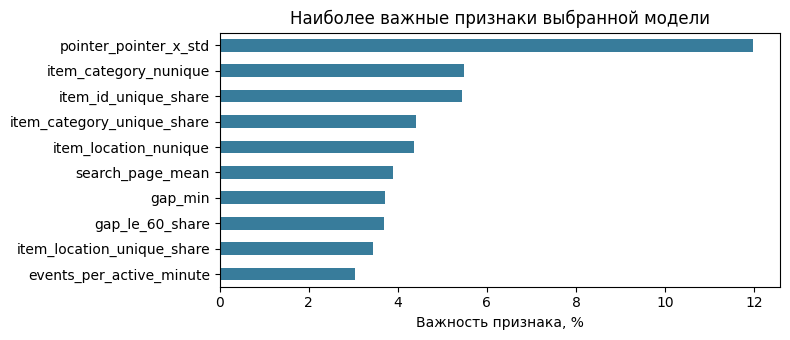

In [27]:
importance = pd.Series(valid_model.feature_importances_, index=X_final.columns)

importance.nlargest(10).sort_values().plot.barh(figsize=(8, 3.5), color='#387c9b')

plt.xlabel('Важность признака, %')
plt.title('Наиболее важные признаки выбранной модели')
plt.tight_layout()
plt.show()

На позднем фолде итоговая конфигурация Optuna при общем пороге даёт
**TP=112, FP=38, FN=48**, Precision=74.7%, Recall=70.0%.
Для cookies с ≤5 событиями Recall=35.7%.
Важнейший признак — `pointer_pointer_x_std`; его полезность зависит от устройств и сбора данных.

**Ограничения:** оба временных фолда использовались при подборе, а три seed не являются
независимыми выборками. Кандидат Optuna не показал устойчивого локального улучшения.
Финальная модель выбрана после сравнения двух результатов скрытого теста (0,78 и 0,79),
поэтому эта оценка тоже участвовала в отборе. Это не гарантирует переноса на новые периоды.
Отрицательный класс считается человеческим, положительный охватывает известные сервисы;
перенос на неизвестный сервис отдельно не проверен — идентификаторов сервисов нет.

## 6. Финальная модель и submission

Обучаем Optuna-кандидата на всём train с seed 42 и точными параметрами лучшей попытки.
Число деревьев — медиана лучших итераций двух фолдов при этом seed: (904 + 1000) / 2 = **952**.
Тест получает непрерывные scores; сохраняем порядок `sample_submission.csv`, оценки не округляем.
Создаваемый **`submission.csv`** соответствует варианту, получившему сообщённую оценку **0,79**.

In [28]:
final_model = catboost(iterations).set_params(**final_params)
final_model.fit(X_final.fillna(-999), y)

X_test_base = build_features(ev_test, test).reindex(columns=X.columns)
X_test = feature_variants(X_test_base, ev_test)[best_name].reindex(columns=X_final.columns)

submission = pd.DataFrame({
    'cookie_id': test.cookie_id,
    'score': final_model.predict_proba(X_test.fillna(-999))[:, 1],
})
submission = sample[['cookie_id']].merge(
    submission, on='cookie_id', validate='one_to_one', sort=False,
)

assert submission.cookie_id.is_unique and len(submission) == len(test)
assert (
    submission.cookie_id.tolist() == sample.cookie_id.tolist()
    and set(submission.cookie_id) == set(test.cookie_id)
)
assert np.isfinite(submission.score).all() and submission.score.between(0, 1).all()

submission.to_csv('submission.csv', index=False)
print(f'Сохранён submission.csv: {len(submission)} строк, {iterations} деревьев, вариант {best_name}')

submission.head()

Сохранён submission.csv: 4909 строк, 952 деревьев, вариант Паузы 1–99%


,cookie_id,score
0,ck_99a4e5ef02d89493,0.022173
1,ck_54d463f7fd89ec3d,0.027821
2,ck_0fbbc7a6af300368,0.002864
3,ck_8fd4937eadd64fb6,0.008599
4,ck_dbb4bd4eda97255d,0.011957


**Источники и воспроизводимость.** Использованы NumPy, pandas, scikit-learn, CatBoost, Optuna и matplotlib;
версии зафиксированы в `requirements.txt`. Метрика и двухпризнаковый baseline взяты из материалов задания.
Агрегации событий, временные разбиения и сравнения реализованы в этом ноутбуке.
Внешние API и языковые модели в решении не используются. Идентификаторы отдельных cookies
не используются для задания ответов. Код запускается целиком из исходных CSV.